In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
    # Load all CSV files
student_info = pd.read_csv('../data/studentInfo.csv')
student_assessment = pd.read_csv('../data/studentAssessment.csv')
student_vle = pd.read_csv('../data/studentVle.csv')
student_registration = pd.read_csv('../data/studentRegistration.csv')
assessments = pd.read_csv('../data/assessments.csv')
courses = pd.read_csv('../data/courses.csv')
vle = pd.read_csv('../data/vle.csv')

print("All datasets loaded!")
print(f"studentInfo shape:         {student_info.shape}")
print(f"studentAssessment shape:   {student_assessment.shape}")
print(f"studentVle shape:          {student_vle.shape}")
print(f"studentRegistration shape: {student_registration.shape}")
print(f"assessments shape:         {assessments.shape}")
print(f"courses shape:             {courses.shape}")
print(f"vle shape:                 {vle.shape}")

All datasets loaded!
studentInfo shape:         (32593, 12)
studentAssessment shape:   (173912, 5)
studentVle shape:          (10655280, 6)
studentRegistration shape: (32593, 5)
assessments shape:         (206, 6)
courses shape:             (22, 3)
vle shape:                 (6364, 6)


In [7]:
print("=== studentInfo - First 5 rows ===")
print(student_info.head())

print("\n=== Column names ===")
print(student_info.columns.tolist())

print("\n=== Data types ===")
print(student_info.dtypes)

=== studentInfo - First 5 rows ===
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1        

In [8]:
print("=== Missing values in studentInfo ===")
missing = student_info.isnull().sum()
missing_pct = (missing / len(student_info) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing values in studentInfo ===
          Missing Count  Missing %
imd_band           1111       3.41


In [9]:
print("=== Target variable: final_result ===")
print(student_info['final_result'].value_counts())
print()

=== Target variable: final_result ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64



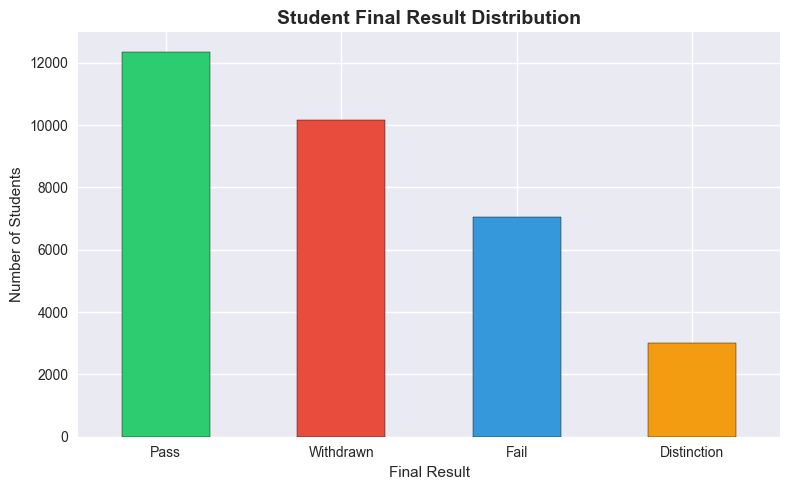

Plot saved!


In [10]:
# Plotting
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
student_info['final_result'].value_counts().plot(
    kind='bar', color=colors, edgecolor='black'
)
plt.title('Student Final Result Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/target_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

<Figure size 1000x500 with 0 Axes>

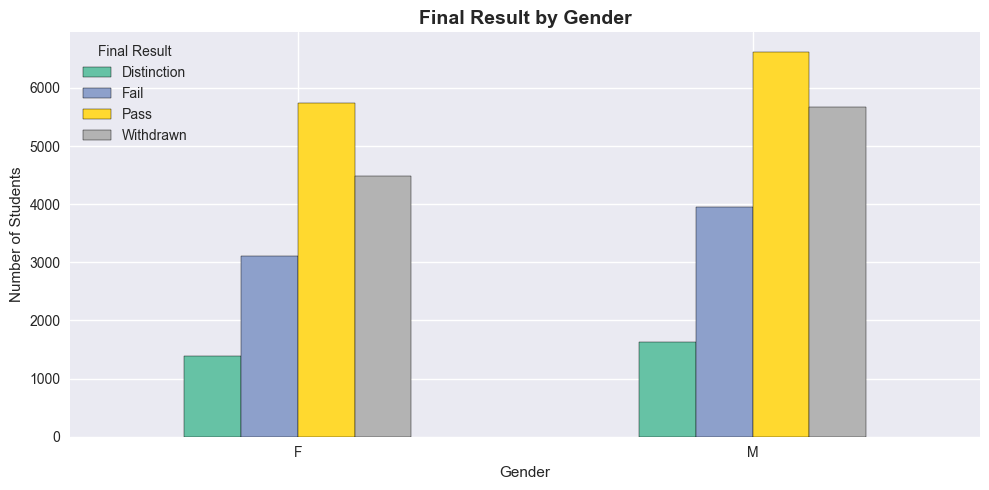

In [11]:
#Dropout breakdown by gender
plt.figure(figsize=(10, 5))
dropout_gender = student_info.groupby(['gender', 'final_result']).size().unstack()
dropout_gender.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Final Result by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Final Result')
plt.tight_layout()
plt.savefig('../data/result_by_gender.png', dpi=150)
plt.show()

<Figure size 1200x500 with 0 Axes>

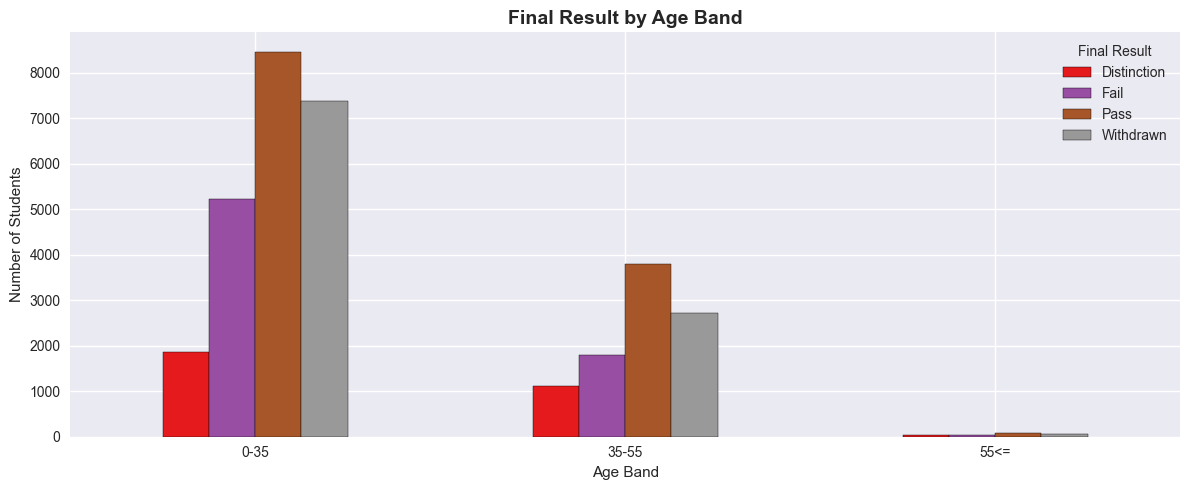

In [13]:
#Dropout by age band
plt.figure(figsize=(12, 5))
dropout_age = student_info.groupby(['age_band', 'final_result']).size().unstack()
dropout_age.plot(kind='bar', figsize=(12, 5), colormap='Set1', edgecolor='black')
plt.title('Final Result by Age Band', fontsize=14, fontweight='bold')
plt.xlabel('Age Band')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Final Result')
plt.tight_layout()
plt.savefig('../data/result_by_age.png', dpi=150)
plt.show()

<Figure size 1000x500 with 0 Axes>

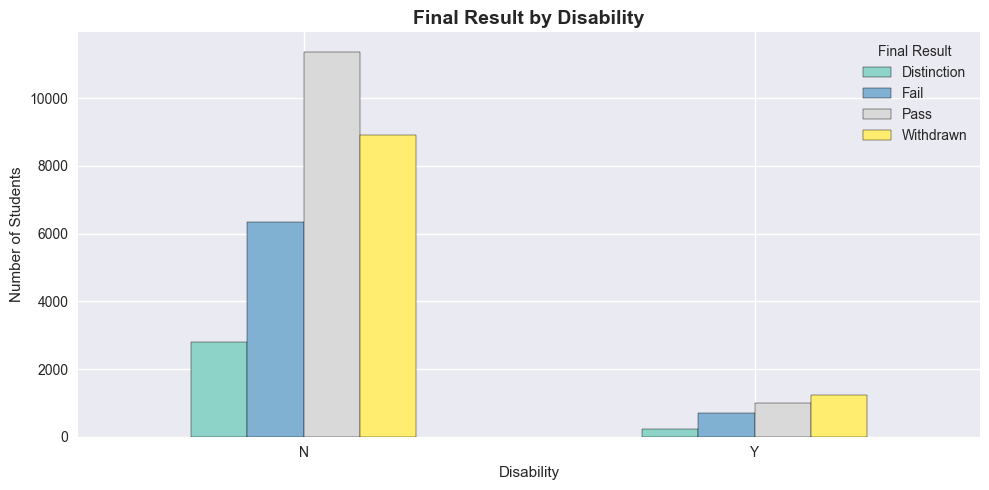

In [14]:
#Dropout by disability
plt.figure(figsize=(10, 5))
dropout_disability = student_info.groupby(
    ['disability', 'final_result']).size().unstack()
dropout_disability.plot(
    kind='bar', figsize=(10, 5), colormap='Set3', edgecolor='black')
plt.title('Final Result by Disability', fontsize=14, fontweight='bold')
plt.xlabel('Disability')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Final Result')
plt.tight_layout()
plt.savefig('../data/result_by_disability.png', dpi=150)
plt.show()

<Figure size 1400x600 with 0 Axes>

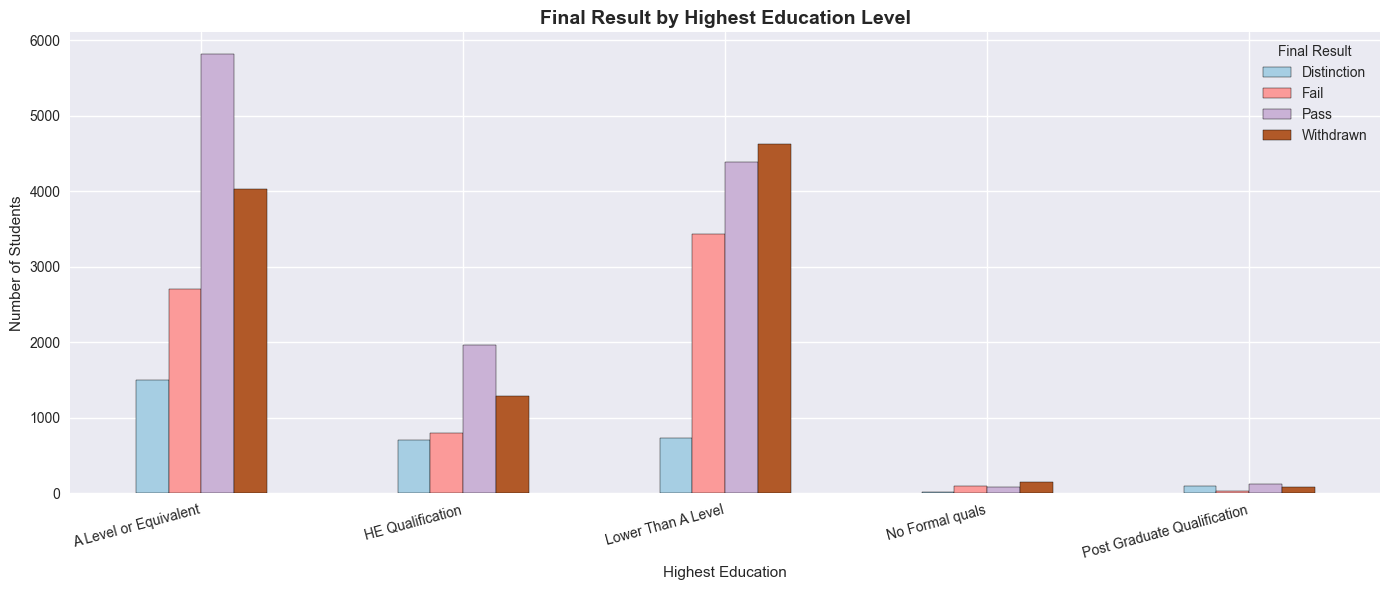

In [15]:
#Key insight: previous education impact
plt.figure(figsize=(14, 6))
dropout_edu = student_info.groupby(
    ['highest_education', 'final_result']).size().unstack()
dropout_edu.plot(kind='bar', figsize=(14, 6), colormap='Paired', edgecolor='black')
plt.title('Final Result by Highest Education Level', 
          fontsize=14, fontweight='bold')
plt.xlabel('Highest Education')
plt.ylabel('Number of Students')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Final Result')
plt.tight_layout()
plt.savefig('../data/result_by_education.png', dpi=150)
plt.show()

In [16]:
#Summary statistics
total = len(student_info)
withdrawn = len(student_info[student_info['final_result'] == 'Withdrawn'])
failed = len(student_info[student_info['final_result'] == 'Fail'])
passed = len(student_info[student_info['final_result'] == 'Pass'])
distinction = len(student_info[student_info['final_result'] == 'Distinction'])

print("=" * 50)
print("       KEY EDA FINDINGS SUMMARY")
print("=" * 50)
print(f"Total students analysed:     {total:,}")
print(f"Withdrawal rate:             {withdrawn/total*100:.1f}%")
print(f"Failure rate:                {failed/total*100:.1f}%")
print(f"Pass rate:                   {passed/total*100:.1f}%")
print(f"Distinction rate:            {distinction/total*100:.1f}%")
print(f"\nAt-risk students (W + F):    {(withdrawn+failed):,}")
print(f"At-risk rate:                {(withdrawn+failed)/total*100:.1f}%")
print("=" * 50)

       KEY EDA FINDINGS SUMMARY
Total students analysed:     32,593
Withdrawal rate:             31.2%
Failure rate:                21.6%
Pass rate:                   37.9%
Distinction rate:            9.3%

At-risk students (W + F):    17,208
At-risk rate:                52.8%
